## Baseline et modèle simple

On part du fichier nettoyé df_clean.csv produit dans le notebook 1.

On compare ici deux approches :
- une baseline très simple : prédire RainTomorrow avec RainToday ;
- une régression logistique, entraînée station par station avec un split temporel.

## Chargement des données

On repart de la version nettoyée afin de garder le notebook centré sur la modélisation.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.insert(0, "../src")
from weather_data import load_clean_weather
from weather_modeling import evaluate_logreg_by_location, evaluate_naive_by_location

df = load_clean_weather(add_binary_targets=True)
df = df.dropna(subset=["Date", "RainTomorrow_bin"]).copy()
print(df.shape)
df.head()

(142193, 21)


,Date,Location,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainToday_bin,RainTomorrow_bin
0,2008-07-01,Adelaide,8.8,15.7,5.0,NW,48.0,SW,W,13.0,...,92.0,67.0,1017.4,1017.7,13.5,14.9,Yes,No,1,0.0
1,2008-07-02,Adelaide,12.7,15.8,0.8,SW,35.0,SSW,SW,13.0,...,75.0,52.0,1022.4,1022.6,13.7,15.5,No,No,0,0.0
2,2008-07-03,Adelaide,6.2,15.1,0.0,W,20.0,NNE,SW,2.0,...,81.0,56.0,1027.8,1026.5,9.3,13.9,No,No,0,0.0
3,2008-07-04,Adelaide,5.3,15.9,0.0,NNE,30.0,NNE,NE,6.0,...,71.0,46.0,1028.7,1025.6,10.2,15.3,No,No,0,0.0
5,2008-07-06,Adelaide,11.3,15.7,8.1,NNW,52.0,NNE,NNW,15.0,...,62.0,62.0,1019.5,1016.2,13.0,14.4,Yes,Yes,1,1.0


In [8]:
feature_cols = df.select_dtypes(include=np.number).columns.tolist()
feature_cols = [col for col in feature_cols if col != "RainTomorrow_bin"]
feature_cols

['MinTemp',
 'MaxTemp',
 'Rainfall',
 'WindGustSpeed',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Temp9am',
 'Temp3pm',
 'RainToday_bin']

## Cadre d'évaluation

Les fonctions d'évaluation sont regroupées dans weather_modeling.py.

La logique reste la même pour les deux approches :
- tri chronologique par station météo ;
- split train/test à 80/20 dans chaque station ;
- agrégation des prédictions pour obtenir un bilan global.

## 1. Baseline déterministe

Cette baseline sert surtout de point de comparaison : elle reproduit simplement la pluie du jour comme prédiction pour le lendemain.

In [9]:
naive_scores, naive_report, naive_cm = evaluate_naive_by_location(df)
naive_report

,precision,recall,f1-score,support
0.0,0.840479,0.840136,0.840308,22050.000000
1.0,0.450592,0.451225,0.450909,6407.000000
accuracy,0.752574,0.752574,0.752574,0.752574
macro avg,0.645536,0.645681,0.645608,28457.000000
weighted avg,0.752697,0.752574,0.752636,28457.000000


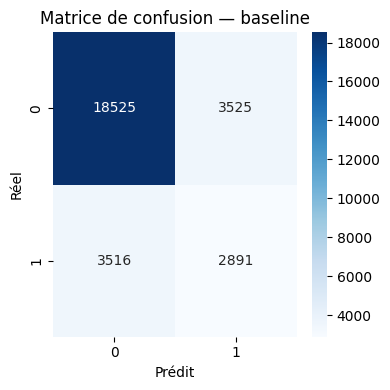

In [4]:
plt.figure(figsize=(4, 4))
sns.heatmap(naive_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion — baseline")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.show()

La baseline capte bien l'inertie de la météo Australienne, ce qui est logique car il pleut peu souvent en Australie, et qu'il y a peu d'alternance pluie/pas pluie/pluie.

## 2. Régression logistique

On garde ici un modèle simple et lisible, avec standardisation et ré-équilibrage des classes.

L'objectif n'est pas encore d'optimiser au maximum les performances, mais d'obtenir un premier modèle probabiliste plus crédible que la baseline.

In [5]:
logreg_scores, logreg_report, logreg_cm, logreg_auc = evaluate_logreg_by_location(df, feature_cols)

logreg_report

,precision,recall,f1-score,support
0.0,0.921644,0.812426,0.863596,22050.000000
1.0,0.541463,0.762291,0.633176,6407.000000
accuracy,0.801139,0.801139,0.801139,0.801139
macro avg,0.731554,0.787359,0.748386,28457.000000
weighted avg,0.836048,0.801139,0.811717,28457.000000


ROC-AUC global : 0.867


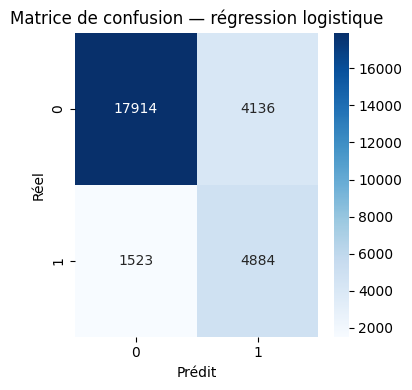

In [6]:
print(f"ROC-AUC global : {logreg_auc:.3f}")

plt.figure(figsize=(4, 4))
sns.heatmap(logreg_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion — régression logistique")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.show()

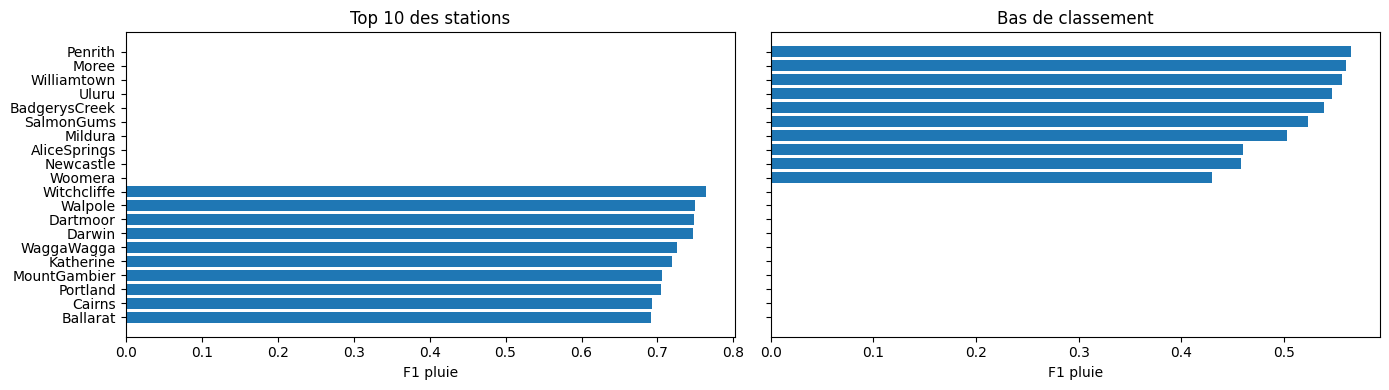

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

top10 = logreg_scores.head(10).sort_values("F1_pluie")
bottom10 = logreg_scores.tail(10).sort_values("F1_pluie")

axes[0].barh(top10["Location"], top10["F1_pluie"])
axes[0].set_title("Top 10 des stations")
axes[0].set_xlabel("F1 pluie")

axes[1].barh(bottom10["Location"], bottom10["F1_pluie"])
axes[1].set_title("Bas de classement")
axes[1].set_xlabel("F1 pluie")

plt.tight_layout()
plt.show()

## Conclusion

La baseline donne une référence utile, mais la régression logistique franchit clairement un cap en combinant les variables météorologiques nettoyées.

Pour les modèles de boosting et de deep, on changera de logique dans le notebook 3 :
- on repartira du fichier brut ;
- on utilisera un split temporel global ;
- le pré-traitement sera adapté séparément à CatBoost et au réseau dense.